# Linear Regression - Complete Guide with All Techniques

A **comprehensive, hands-on guide** covering every major linear regression technique — from mathematical foundations to advanced regularization, diagnostics, and model comparison.

---

## Table of Contents

| # | Section | What You'll Learn |
|---|---------|-------------------|
| 1 | **Setup & Imports** | Load all libraries needed for the entire notebook |
| 2 | **Data Loading & Understanding** | Load Boston Housing data, understand each feature |
| 3 | **Exploratory Data Analysis (EDA)** | Distributions, correlations, outliers, pairplots |
| 4 | **Data Preprocessing** | Train-test split, handling the target variable |
| 5 | **Simple Linear Regression** | One feature → one target, OLS math from scratch, then sklearn |
| 6 | **Multiple Linear Regression** | All features together, interpreting coefficients |
| 7 | **Polynomial Regression** | Capturing non-linear patterns with PolynomialFeatures |
| 8 | **Feature Scaling** | Why scaling matters — StandardScaler vs MinMaxScaler |
| 9 | **Ridge Regression (L2)** | L2 regularization — shrink coefficients, reduce overfitting |
| 10 | **Lasso Regression (L1)** | L1 regularization — automatic feature selection |
| 11 | **Elastic Net** | Best of both Ridge + Lasso |
| 12 | **Cross-Validation & Hyperparameter Tuning** | KFold, GridSearchCV, learning curves |
| 13 | **Assumption Checking & Diagnostics** | Linearity, normality, homoscedasticity, multicollinearity (VIF) |
| 14 | **Statistical Validation (statsmodels)** | p-values, F-test, confidence intervals, Durbin-Watson |
| 15 | **Final Model Comparison & Summary** | Side-by-side metric table, key takeaways |

**Dataset:** Boston Housing — predict median home value (`medv`) from 13 features.

---

## 1. Setup & Imports

> **Why do we import everything upfront?**  
> It keeps the notebook clean and lets us catch missing packages early — before we're deep into analysis.

In [1]:
# ── Core Libraries ──
import numpy as np
import pandas as pd

# ── Visualization ──
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

# ── Sklearn: Models ──
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# ── Sklearn: Preprocessing & Feature Engineering ──
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline, Pipeline

# ── Sklearn: Model Selection & Evaluation ──
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Statistical Modelling ──
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# ── Suppress warnings for cleaner output ──
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


---

## 2. Data Loading & Understanding

> **What is the Boston Housing dataset?**  
> It contains 506 observations of housing in Boston suburbs. Each row has 13 features (crime rate, number of rooms, distance to employment centres, etc.) and a target variable `medv` — the **median value** of owner-occupied homes in $1000s.
>
> **Our goal:** Build a regression model that predicts `medv` from the 13 features.

### Feature Dictionary

| Feature | Description |
|---------|-------------|
| `crim` | Per-capita crime rate by town |
| `zn` | Proportion of residential land zoned for lots > 25,000 sq ft |
| `indus` | Proportion of non-retail business acres per town |
| `chas` | Charles River dummy (1 if tract bounds river; 0 otherwise) |
| `nox` | Nitric oxide concentration (parts per 10 million) |
| `rm` | Average number of rooms per dwelling |
| `age` | Proportion of owner-occupied units built before 1940 |
| `dis` | Weighted distances to five Boston employment centres |
| `rad` | Index of accessibility to radial highways |
| `tax` | Full-value property-tax rate per $10,000 |
| `ptratio` | Pupil-teacher ratio by town |
| `b` | 1000(Bk − 0.63)^2 where Bk = proportion of Black residents |
| `lstat` | Percentage lower status of the population |
| **`medv`** | **Median value of owner-occupied homes in $1000s (TARGET)** |

In [2]:
# Load the dataset
df = pd.read_csv("BostonHousing.csv")

# Quick look at the first 5 rows
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.head()

Dataset shape: 506 rows x 14 columns



,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


> **What to look for in `.info()`:**  
> - Are there any **missing values** (Non-Null Count < 506)?  
> - Are all columns **numeric** (float64 / int64)?  
> - Is `chas` categorical disguised as integer?

In [3]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Total missing values: 0


In [5]:
# Descriptive statistics — look for unusual min/max values, large standard deviations
df.describe().round(2)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


---

## 3. Exploratory Data Analysis (EDA)

> **Why EDA before modelling?**  
> EDA helps us understand:
> 1. **Distribution** of each variable — is it skewed? are there outliers?
> 2. **Relationships** between features and the target — which features are most predictive?
> 3. **Correlations** between features — multicollinearity can hurt linear models.
>
> Skipping EDA is like driving blindfolded — you might reach the destination, but probably won't.

### 3.1 Target Variable Distribution

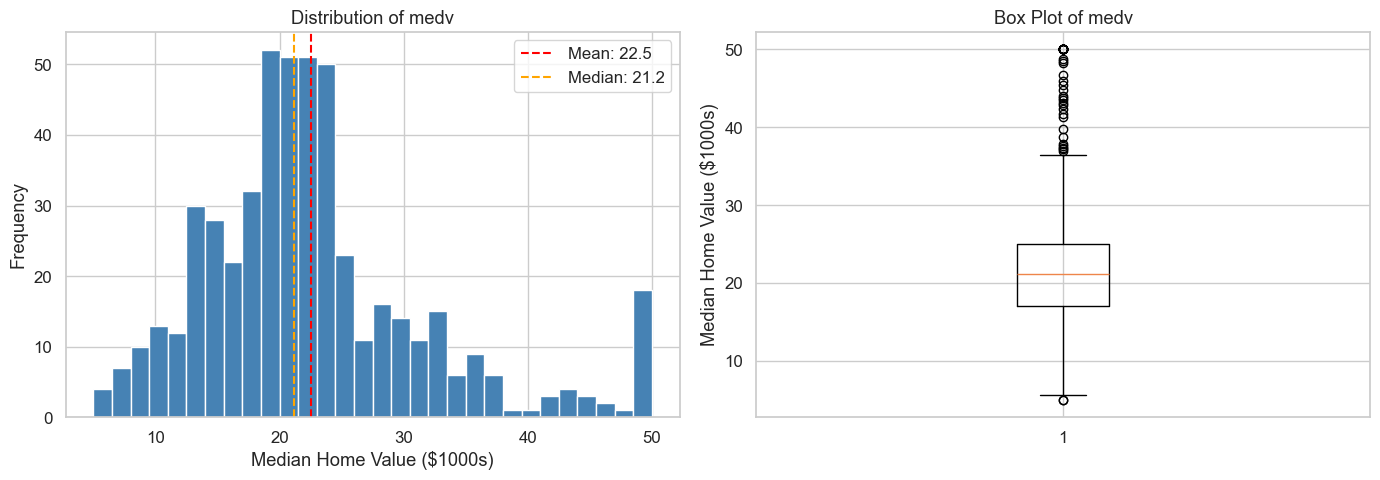

Skewness: 1.108
Kurtosis: 1.495


In [6]:
# Distribution of the target variable (medv)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['medv'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Median Home Value ($1000s)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of medv')
axes[0].axvline(df['medv'].mean(), color='red', linestyle='--', label=f"Mean: {df['medv'].mean():.1f}")
axes[0].axvline(df['medv'].median(), color='orange', linestyle='--', label=f"Median: {df['medv'].median():.1f}")
axes[0].legend()

# Box plot
axes[1].boxplot(df['medv'], vert=True)
axes[1].set_ylabel('Median Home Value ($1000s)')
axes[1].set_title('Box Plot of medv')

plt.tight_layout()
plt.show()

print(f"Skewness: {df['medv'].skew():.3f}")
print(f"Kurtosis: {df['medv'].kurtosis():.3f}")

> **Observations:**
> - `medv` is **right-skewed** (positive skewness) — a few very expensive homes pull the tail.
> - The spike at $50k suggests the data may be **capped** at 50 (censored data).
> - The box plot shows **outliers** on the high end.

### 3.2 Feature Distributions

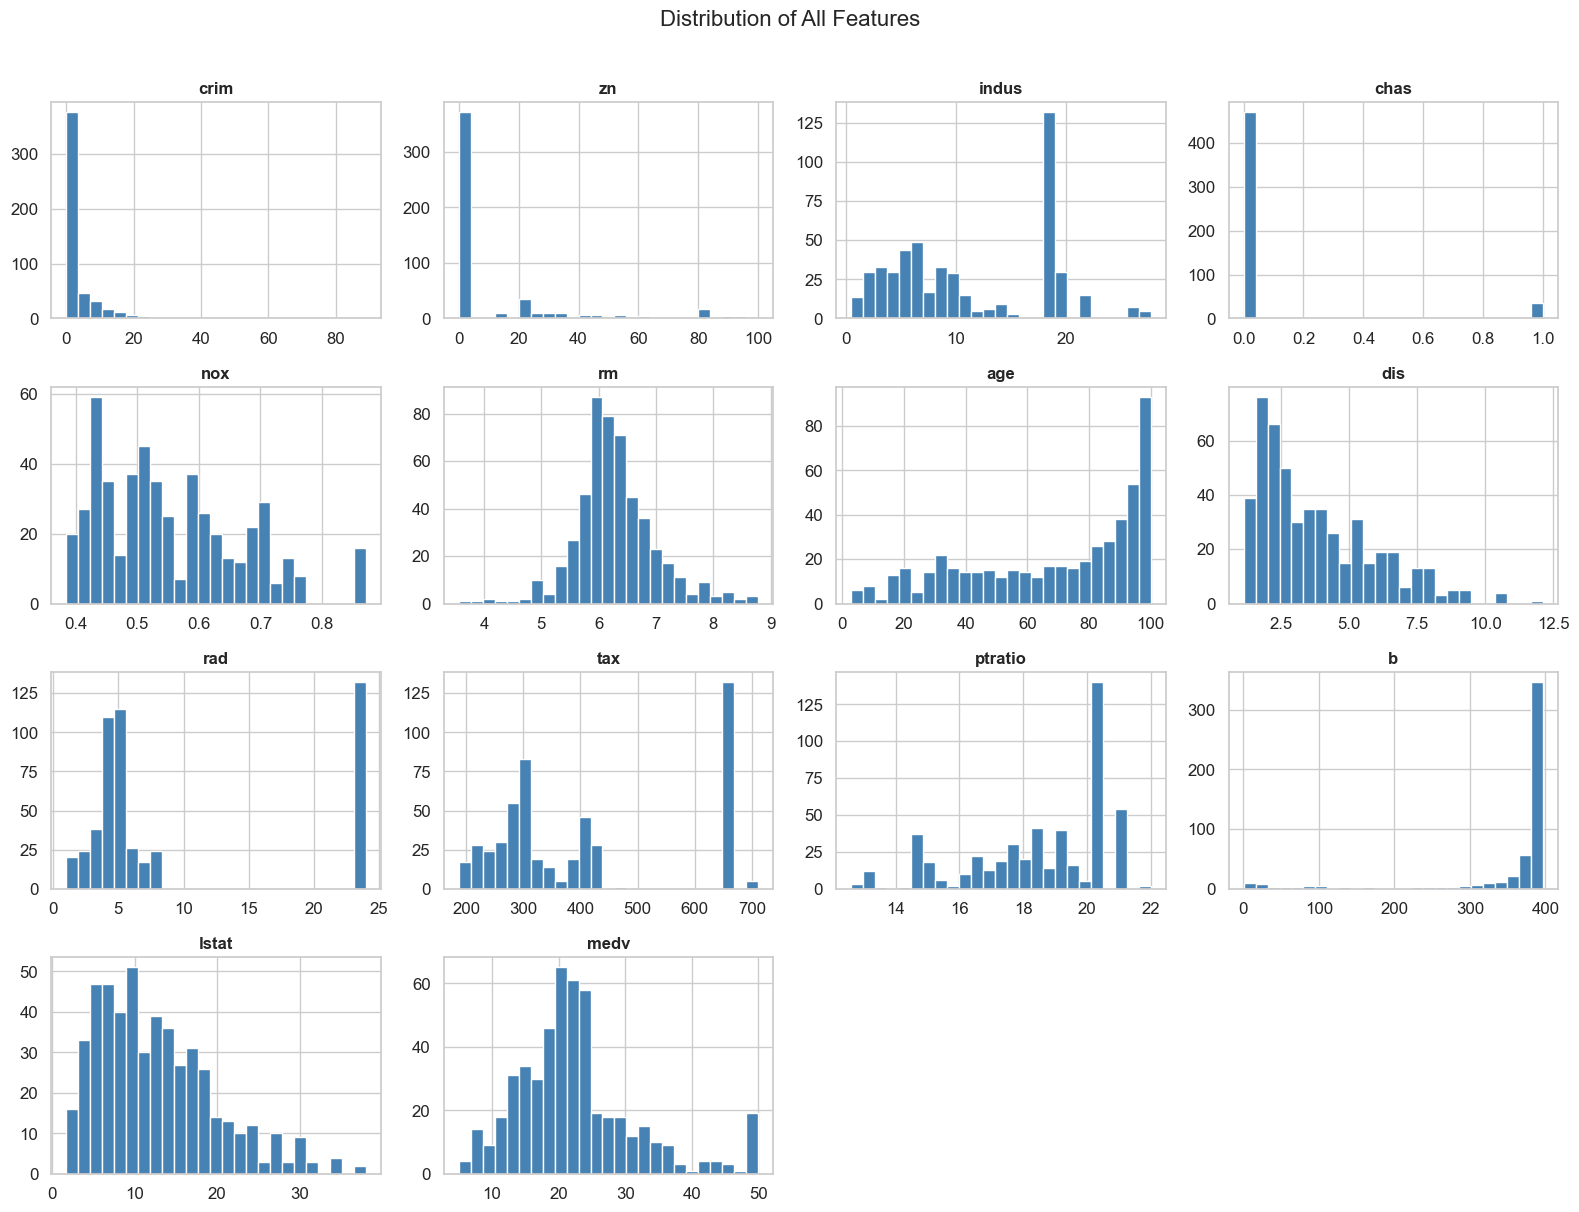

In [7]:
# Distribution of all features — histograms
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')

# Hide unused subplots
for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Correlation Analysis

> **Why check correlations?**
> - **Feature ↔ Target correlation** tells us which features are most useful for prediction.
> - **Feature ↔ Feature correlation** reveals **multicollinearity** — when two features are highly correlated, they carry redundant information, which can make coefficient estimates unstable.

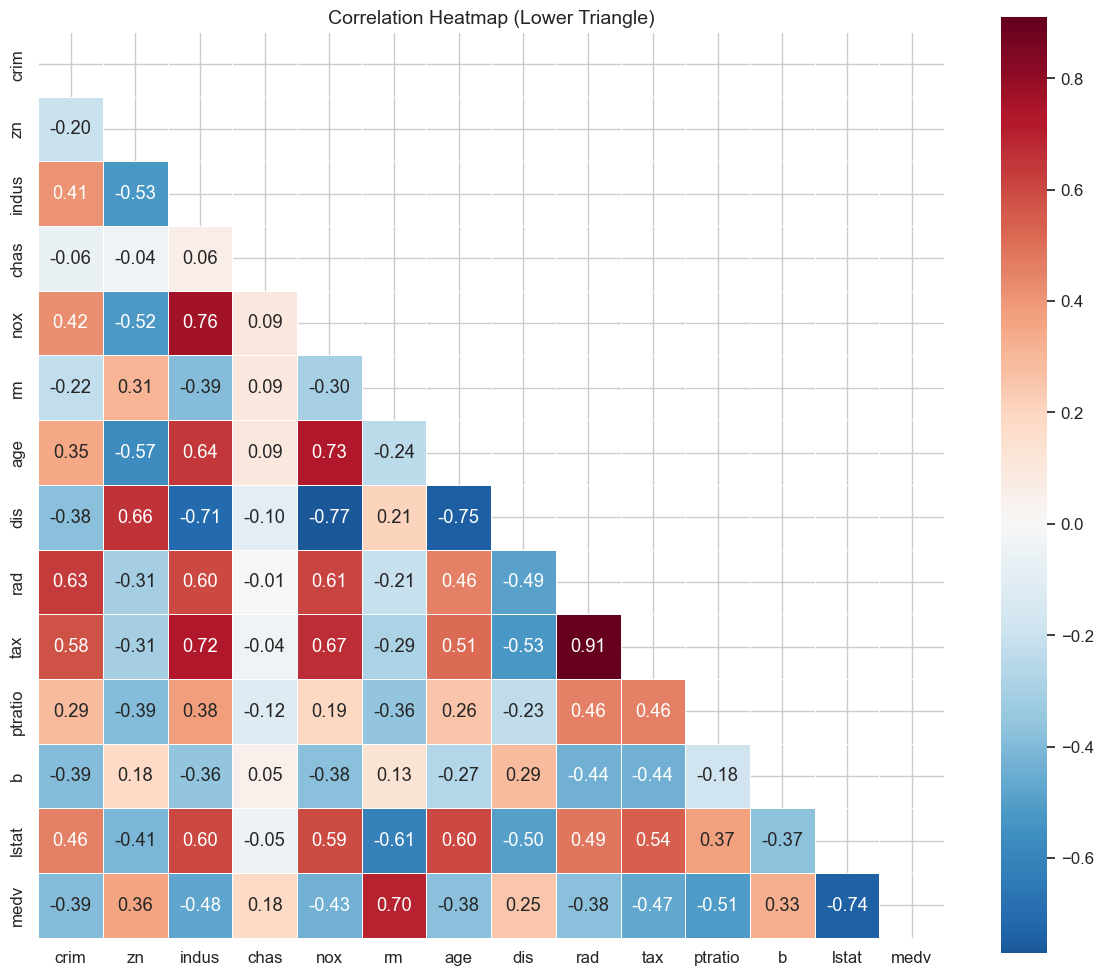

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.corr().round(2)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle to reduce clutter
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, mask=mask,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Top correlations with the target variable (medv)
target_corr = df.corr()['medv'].drop('medv').sort_values(ascending=False)
print("Correlation of each feature with medv (target):\n")
print(target_corr.to_string())

print(f"\n--- Strongest positive correlation: {target_corr.index[0]} ({target_corr.iloc[0]:.3f})")
print(f"--- Strongest negative correlation: {target_corr.index[-1]} ({target_corr.iloc[-1]:.3f})")

Correlation of each feature with medv (target):

rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663

--- Strongest positive correlation: rm (0.695)
--- Strongest negative correlation: lstat (-0.738)


### 3.4 Scatter Plots — Key Features vs Target

> We'll plot the **top 4 most correlated features** against `medv` to visually inspect:
> - Is the relationship **linear**?
> - Are there **outliers** pulling the relationship?

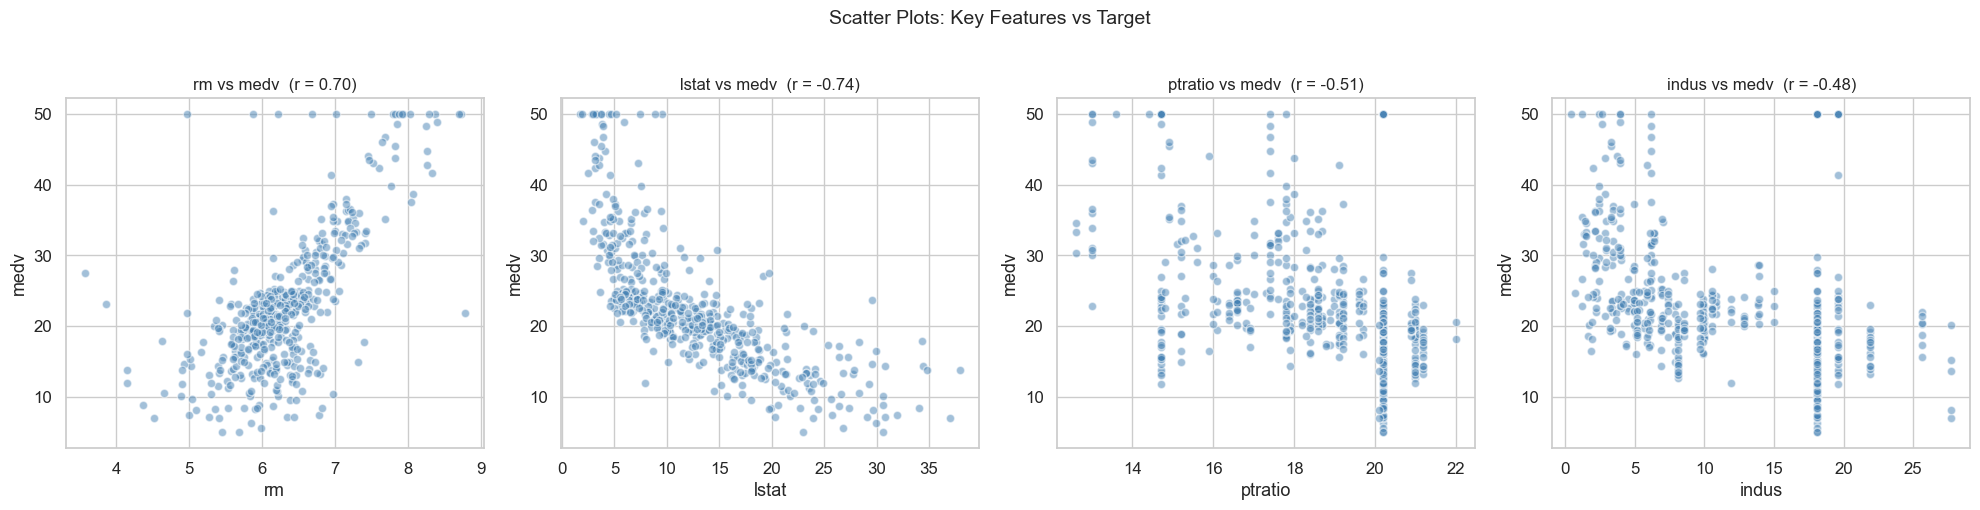

In [10]:
# Scatter plots: top correlated features vs medv
top_features = ['rm', 'lstat', 'ptratio', 'indus']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['medv'], alpha=0.5, color='steelblue', edgecolors='white')
    axes[i].set_xlabel(feat, fontsize=13)
    axes[i].set_ylabel('medv', fontsize=13)
    corr_val = df[feat].corr(df['medv'])
    axes[i].set_title(f'{feat} vs medv  (r = {corr_val:.2f})', fontsize=12)

plt.suptitle('Scatter Plots: Key Features vs Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

> **Key EDA Findings:**
> - `rm` (rooms) has the strongest **positive** correlation (+0.70) — more rooms → higher price.
> - `lstat` (lower status %) has the strongest **negative** correlation (−0.74) — higher lstat → lower price.
> - `lstat` vs `medv` shows a **non-linear** (curved) relationship — polynomial regression might help!
> - `rad` and `tax` are highly correlated with each other (0.91) — watch for multicollinearity.

---

## 4. Data Preprocessing — Train-Test Split

> **Why split before modelling?**  
> We split the data into **training** (80%) and **test** (20%) sets. The model learns patterns ONLY from training data. The test set is held back to evaluate how well the model **generalizes** to unseen data.
>
> **Why `random_state=42`?** It ensures reproducibility — everyone running this notebook gets the same split.

In [11]:
# Separate features (X) and target (y)
X = df.drop('medv', axis=1)
y = df['medv']

print(f"Features shape: {X.shape}  →  {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target shape:   {y.shape}")

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Features shape: (506, 13)  →  506 samples, 13 features
Target shape:   (506,)

Training set: 404 samples
Test set:     102 samples


### Helper Function — Evaluate & Store Model Results

> We'll use this function throughout the notebook to consistently evaluate every model and store results for the final comparison table.

In [12]:
# Dictionary to store results from every model
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train the model, predict, compute metrics, store results, and print a summary."""
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_te)

    train_r2 = r2_score(y_tr, y_pred_train)
    test_r2 = r2_score(y_te, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred_test))
    mae = mean_absolute_error(y_te, y_pred_test)

    results[name] = {
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4)
    }

    print(f"{'='*50}")
    print(f"  Model: {name}")
    print(f"{'='*50}")
    print(f"  Train R²  : {train_r2:.4f}")
    print(f"  Test  R²  : {test_r2:.4f}")
    print(f"  RMSE      : {rmse:.4f}")
    print(f"  MAE       : {mae:.4f}")
    print(f"{'='*50}")
    
    return y_pred_test

---

## 5. Simple Linear Regression (Univariate)

> **What is Simple Linear Regression?**  
> It models the relationship between **one** independent variable (X) and the target (y) using a straight line:
>
> $$\hat{y} = w_0 + w_1 \cdot X$$
>
> Where:
> - $w_0$ = **intercept** (value of y when X = 0)
> - $w_1$ = **slope** (how much y changes for a 1-unit increase in X)
>
> **How does it find the best line?** Using **Ordinary Least Squares (OLS)** — it minimizes the sum of squared residuals:
>
> $$\text{minimize} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
>
> We'll use `lstat` (strongest negative correlation with `medv`) as our single feature.

### 5.1 OLS from Scratch (using NumPy)

> Before using sklearn, let's compute the slope and intercept **manually** using the OLS formulas:
>
> $$w_1 = \frac{\sum (X_i - \bar{X})(y_i - \bar{y})}{\sum (X_i - \bar{X})^2} \qquad w_0 = \bar{y} - w_1 \cdot \bar{X}$$

In [13]:
# ── Simple Linear Regression: OLS from scratch ──

# Use only 'lstat' as the single feature
X_simple_train = X_train['lstat'].values
y_simple_train = y_train.values
X_simple_test = X_test['lstat'].values
y_simple_test = y_test.values

# Step 1: Compute means
X_mean = X_simple_train.mean()
y_mean = y_simple_train.mean()

# Step 2: Compute slope (w1) using OLS formula
numerator = np.sum((X_simple_train - X_mean) * (y_simple_train - y_mean))
denominator = np.sum((X_simple_train - X_mean) ** 2)
w1 = numerator / denominator

# Step 3: Compute intercept (w0)
w0 = y_mean - w1 * X_mean

print(f"OLS from scratch:")
print(f"  Intercept (w0) = {w0:.4f}")
print(f"  Slope     (w1) = {w1:.4f}")
print(f"\n  Equation:  medv = {w0:.2f} + ({w1:.2f}) * lstat")
print(f"  Interpretation: For every 1-unit increase in lstat, medv decreases by ${abs(w1)*1000:.0f}")

OLS from scratch:
  Intercept (w0) = 34.8369
  Slope     (w1) = -0.9665

  Equation:  medv = 34.84 + (-0.97) * lstat
  Interpretation: For every 1-unit increase in lstat, medv decreases by $967


### 5.2 Simple Linear Regression with sklearn

> Now let's verify our manual calculation matches sklearn's `LinearRegression`.

In [14]:
# ── Simple Linear Regression with sklearn ──
lr_simple = LinearRegression()
lr_simple.fit(X_simple_train.reshape(-1, 1), y_simple_train)

print(f"sklearn results:")
print(f"  Intercept = {lr_simple.intercept_:.4f}")
print(f"  Slope     = {lr_simple.coef_[0]:.4f}")
print(f"\n  Match with our manual calculation? {np.isclose(w0, lr_simple.intercept_) and np.isclose(w1, lr_simple.coef_[0])}")

sklearn results:
  Intercept = 34.8369
  Slope     = -0.9665

  Match with our manual calculation? True


In [15]:
# Evaluate Simple Linear Regression
y_pred_simple = evaluate_model(
    "Simple LR (lstat only)", lr_simple,
    X_simple_train.reshape(-1, 1), X_simple_test.reshape(-1, 1),
    y_simple_train, y_simple_test
)

  Model: Simple LR (lstat only)
  Train R²  : 0.5423
  Test  R²  : 0.5429
  RMSE      : 5.7896
  MAE       : 4.1848


### 5.3 Visualizing the Regression Line and Residuals

> The **regression line** shows the model's predictions. **Residuals** (= actual − predicted) show where the model is wrong. Ideally, residuals should be randomly scattered around zero with no pattern.

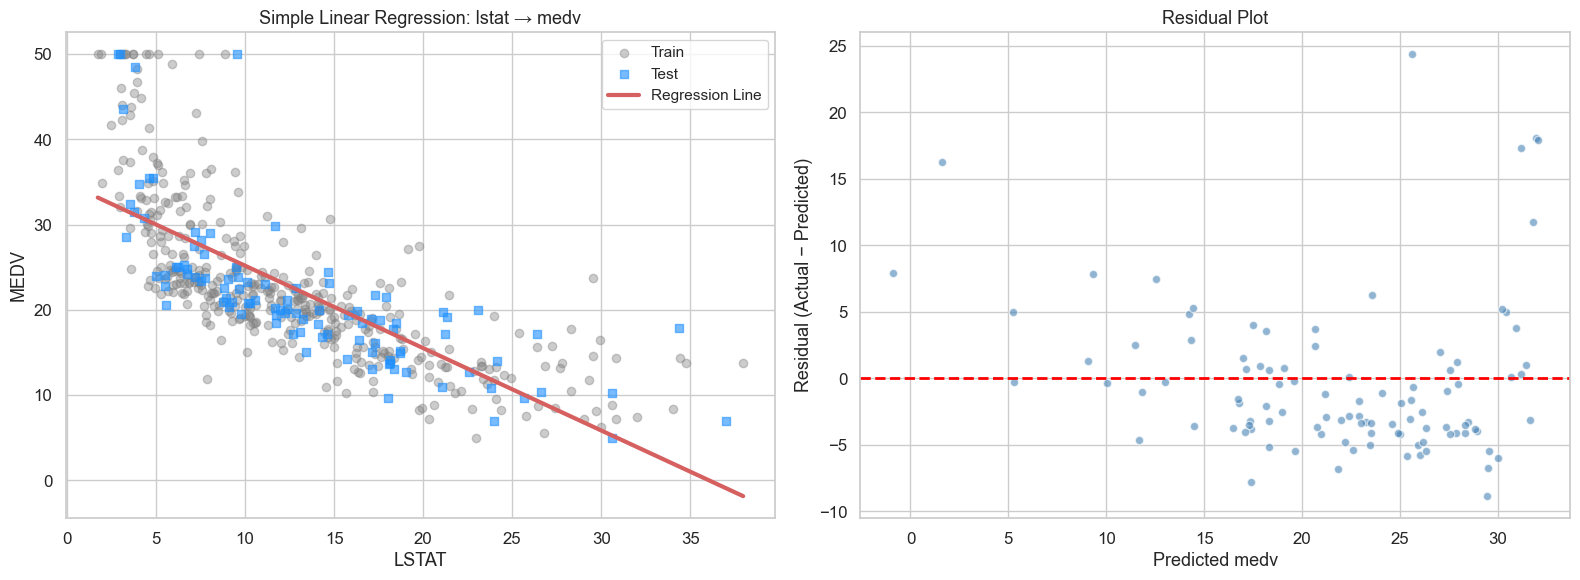

Note: The curved pattern in residuals suggests a NON-LINEAR relationship.
      → Simple linear regression is NOT enough. Let's try more techniques!


In [16]:
# Visualize: Regression Line + Residual Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Regression Line ──
dummy_x = np.linspace(X_simple_train.min(), X_simple_train.max(), 100).reshape(-1, 1)
axes[0].scatter(X_simple_train, y_simple_train, alpha=0.4, color='gray', label='Train')
axes[0].scatter(X_simple_test, y_simple_test, alpha=0.6, color='dodgerblue', marker='s', label='Test')
axes[0].plot(dummy_x, lr_simple.predict(dummy_x), 'r-', lw=3, label='Regression Line')
axes[0].set_xlabel('LSTAT', fontsize=13)
axes[0].set_ylabel('MEDV', fontsize=13)
axes[0].set_title('Simple Linear Regression: lstat → medv', fontsize=13)
axes[0].legend(fontsize=11)

# ── Right: Residual Plot ──
residuals = y_simple_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals, alpha=0.6, color='steelblue', edgecolors='white')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted medv', fontsize=13)
axes[1].set_ylabel('Residual (Actual − Predicted)', fontsize=13)
axes[1].set_title('Residual Plot', fontsize=13)

plt.tight_layout()
plt.show()

print("Note: The curved pattern in residuals suggests a NON-LINEAR relationship.")
print("      → Simple linear regression is NOT enough. Let's try more techniques!")

---

## 6. Multiple Linear Regression

> **What changes with multiple features?**  
> Instead of one slope, we now have a coefficient for **every** feature:
>
> $$\hat{y} = w_0 + w_1 X_1 + w_2 X_2 + \ldots + w_{13} X_{13}$$
>
> Each $w_i$ tells us: *"Holding all other features constant, how much does `medv` change for a 1-unit increase in feature $X_i$?"*
>
> **Advantage:** Using all features captures more information → usually better predictions.  
> **Risk:** Irrelevant or correlated features can introduce noise and multicollinearity.

In [17]:
# ── Multiple Linear Regression: All 13 features ──
lr_multi = LinearRegression()
y_pred_multi = evaluate_model("Multiple LR (all features)", lr_multi, X_train, X_test, y_train, y_test)

  Model: Multiple LR (all features)
  Train R²  : 0.7509
  Test  R²  : 0.6688
  RMSE      : 4.9286
  MAE       : 3.1891


Intercept: 30.2468

Feature Coefficients (sorted by absolute value):
Feature  Coefficient
    nox   -17.202633
     rm     4.438835
   chas     2.784438
    dis    -1.447865
ptratio    -0.915456
  lstat    -0.508571
    rad     0.262430
   crim    -0.113056
  indus     0.040381
     zn     0.030110
      b     0.012351
    tax    -0.010647
    age    -0.006296


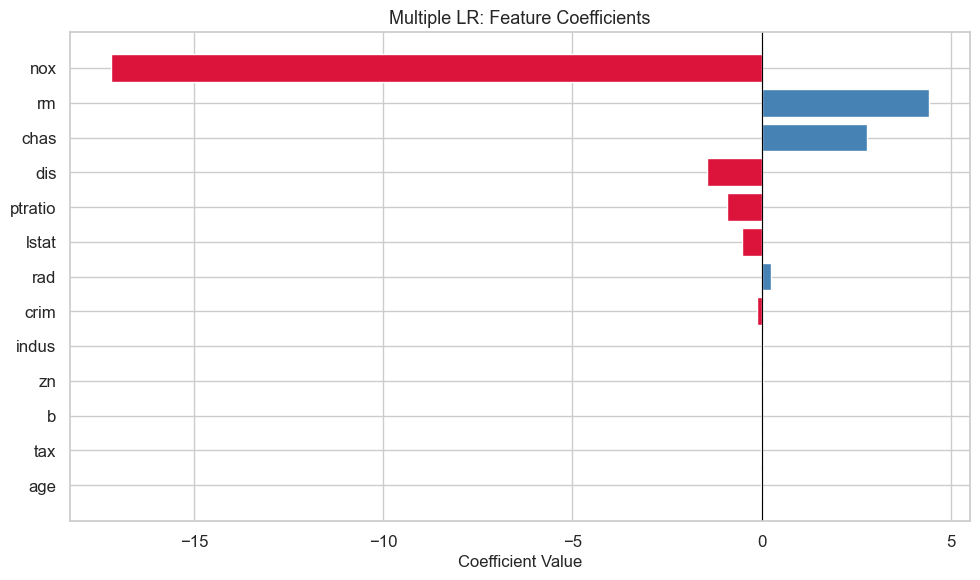

In [18]:
# Interpreting Coefficients — which features matter most?
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_multi.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"Intercept: {lr_multi.intercept_:.4f}\n")
print("Feature Coefficients (sorted by absolute value):")
print(coef_df.to_string(index=False))

# Bar plot of coefficients
plt.figure(figsize=(10, 6))
colors = ['crimson' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Multiple LR: Feature Coefficients', fontsize=13)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

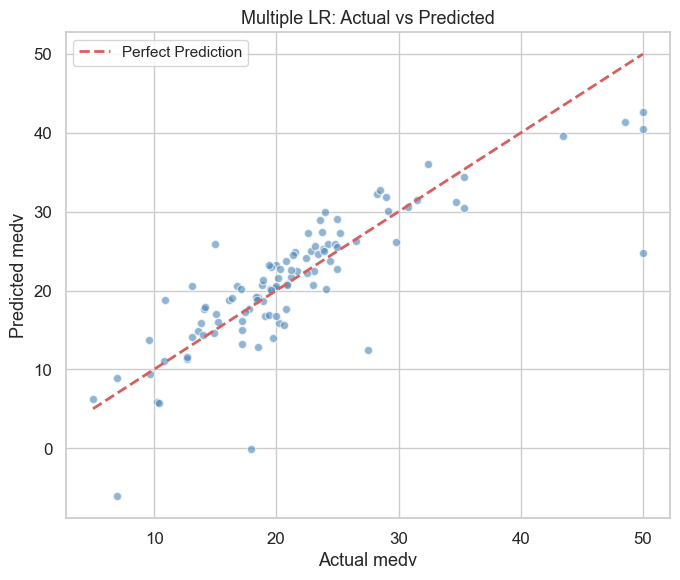

Points closer to the red dashed line = better predictions.


In [19]:
# Actual vs Predicted plot for Multiple LR
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_multi, alpha=0.6, color='steelblue', edgecolors='white')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual medv', fontsize=13)
plt.ylabel('Predicted medv', fontsize=13)
plt.title('Multiple LR: Actual vs Predicted', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Points closer to the red dashed line = better predictions.")

---

## 7. Polynomial Regression

> **What is Polynomial Regression?**  
> When the relationship between X and y is **curved** (non-linear), a straight line won't fit well. Polynomial regression creates new features by raising X to higher powers:
>
> $$\hat{y} = w_0 + w_1 X + w_2 X^2 + w_3 X^3 + \ldots$$
>
> **Key insight:** It's still *linear* regression — linear in the **coefficients** ($w$), not in X. We're just doing feature engineering by adding $X^2, X^3, \ldots$ as new columns.
>
> **Danger of high degrees:** Too many polynomial terms → **overfitting** (memorizes training data, fails on new data).

### 7.1 Polynomial Regression on a Single Feature (lstat)

> Let's compare degree 1 (linear), 2, and 3 polynomials on `lstat` to see how curves improve the fit.

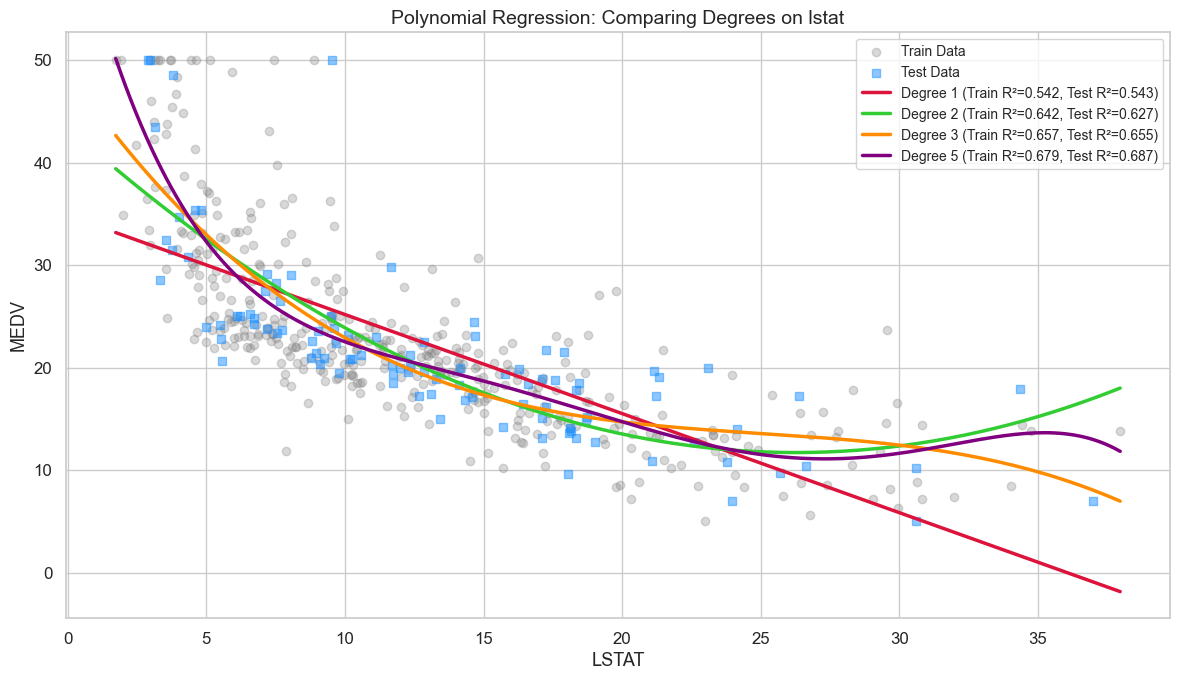

In [20]:
# ── Compare polynomial degrees on lstat ──
X_s_train = X_simple_train.reshape(-1, 1)
X_s_test = X_simple_test.reshape(-1, 1)
dummy_x = np.linspace(X_simple_train.min(), X_simple_train.max(), 200).reshape(-1, 1)

plt.figure(figsize=(12, 7))
plt.scatter(X_simple_train, y_simple_train, alpha=0.3, color='gray', label='Train Data')
plt.scatter(X_simple_test, y_simple_test, alpha=0.5, color='dodgerblue', marker='s', label='Test Data')

colors = ['crimson', 'limegreen', 'darkorange', 'purple']
for deg, color in zip([1, 2, 3, 5], colors):
    pipe = make_pipeline(PolynomialFeatures(degree=deg, include_bias=False), LinearRegression())
    pipe.fit(X_s_train, y_simple_train)
    train_r2 = r2_score(y_simple_train, pipe.predict(X_s_train))
    test_r2 = r2_score(y_simple_test, pipe.predict(X_s_test))
    plt.plot(dummy_x, pipe.predict(dummy_x), color=color, lw=2.5,
             label=f'Degree {deg} (Train R²={train_r2:.3f}, Test R²={test_r2:.3f})')

plt.xlabel('LSTAT', fontsize=13)
plt.ylabel('MEDV', fontsize=13)
plt.title('Polynomial Regression: Comparing Degrees on lstat', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

### 7.2 Overfitting Demo — What Happens with Very High Degree?

> **Overfitting** = model fits the training data TOO well (including noise) but performs poorly on unseen data.  
> As polynomial degree increases, the model becomes more flexible but more prone to overfitting.

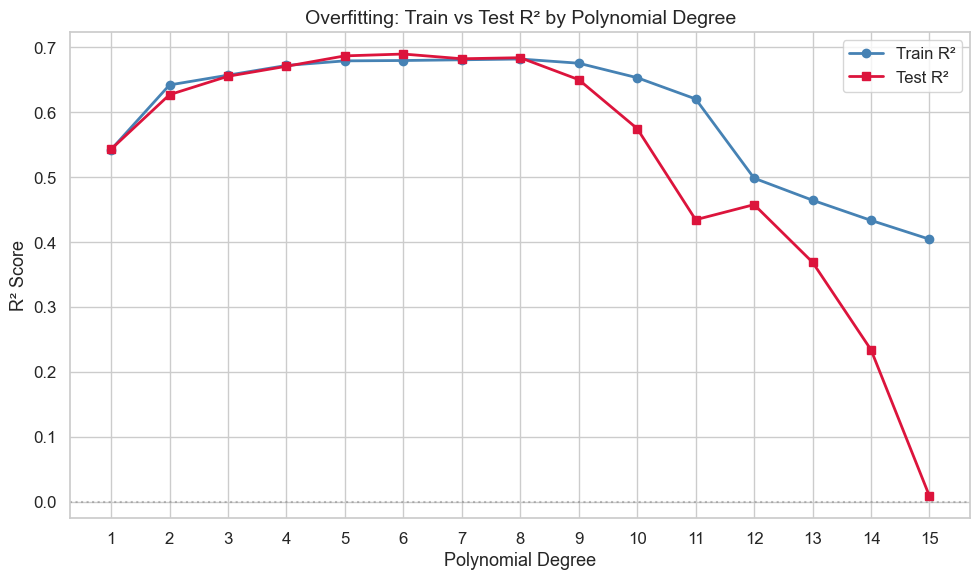

Notice: Train R² keeps increasing, but Test R² drops after degree ~3-5.
This GAP between train and test is the hallmark of OVERFITTING.


In [21]:
# ── Overfitting demo: Train vs Test R² across polynomial degrees ──
degrees = range(1, 16)
train_scores = []
test_scores = []

for deg in degrees:
    pipe = make_pipeline(PolynomialFeatures(degree=deg, include_bias=False), LinearRegression())
    pipe.fit(X_s_train, y_simple_train)
    train_scores.append(r2_score(y_simple_train, pipe.predict(X_s_train)))
    test_scores.append(r2_score(y_simple_test, pipe.predict(X_s_test)))

plt.figure(figsize=(10, 6))
plt.plot(list(degrees), train_scores, 'o-', color='steelblue', lw=2, label='Train R²')
plt.plot(list(degrees), test_scores, 's-', color='crimson', lw=2, label='Test R²')
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Polynomial Degree', fontsize=13)
plt.ylabel('R² Score', fontsize=13)
plt.title('Overfitting: Train vs Test R² by Polynomial Degree', fontsize=14)
plt.legend(fontsize=12)
plt.xticks(list(degrees))
plt.tight_layout()
plt.show()

print("Notice: Train R² keeps increasing, but Test R² drops after degree ~3-5.")
print("This GAP between train and test is the hallmark of OVERFITTING.")

### 7.3 Polynomial Regression on All Features

> Now let's apply a degree-2 polynomial to **all 13 features** — this creates interaction terms (e.g., `rm * lstat`) and squared terms (e.g., `rm²`), capturing non-linear patterns across all variables.

In [22]:
# ── Polynomial Regression (degree=2) on ALL features ──
poly_pipe = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
y_pred_poly = evaluate_model("Polynomial LR (deg=2, all feat)", poly_pipe, X_train, X_test, y_train, y_test)

# How many features were created?
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X_train)
print(f"\nOriginal features: {X_train.shape[1]}")
print(f"Polynomial features (degree=2): {poly.transform(X_train).shape[1]}")
print("(includes original, squared, and all pairwise interaction terms)")

  Model: Polynomial LR (deg=2, all feat)
  Train R²  : 0.9409
  Test  R²  : 0.8056
  RMSE      : 3.7759
  MAE       : 2.5748

Original features: 13
Polynomial features (degree=2): 104
(includes original, squared, and all pairwise interaction terms)


---

## 8. Feature Scaling

> **Why scale features?**
> - Features like `tax` (range: 187–711) and `chas` (range: 0–1) are on very different scales.
> - Plain Linear Regression is **unaffected** by scaling (it adjusts coefficients automatically).
> - But **regularized models** (Ridge, Lasso, Elastic Net) **penalize large coefficients** — if features aren't scaled, the penalty unfairly punishes features with large values.
>
> **Two common scalers:**
>
> | Scaler | Formula | Result Range | When to Use |
> |--------|---------|-------------|-------------|
> | **StandardScaler** | $\frac{X - \mu}{\sigma}$ | mean=0, std=1 | Most cases, especially with outliers |
> | **MinMaxScaler** | $\frac{X - X_{min}}{X_{max} - X_{min}}$ | [0, 1] | When you need bounded values |
>
> **Important rule:** Fit the scaler on **training data only**, then transform both train and test. Never fit on test data (data leakage!).

In [23]:
# ── Feature Scaling Demo ──

# StandardScaler: transforms to mean=0, std=1
scaler_std = StandardScaler()
X_train_scaled = scaler_std.fit_transform(X_train)  # fit on train, transform train
X_test_scaled = scaler_std.transform(X_test)         # only transform test (no fit!)

# MinMaxScaler: transforms to [0, 1]
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

# Show before vs after scaling
comparison = pd.DataFrame({
    'Feature': X.columns,
    'Original Mean': X_train.mean().round(2).values,
    'Original Std': X_train.std().round(2).values,
    'Scaled Mean': X_train_scaled.mean(axis=0).round(4),
    'Scaled Std': X_train_scaled.std(axis=0).round(4),
})
print("Before vs After StandardScaler:")
print(comparison.to_string(index=False))

Before vs After StandardScaler:
Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
   crim           3.61          8.88         -0.0         1.0
     zn          11.57         23.15          0.0         1.0
  indus          10.99          6.89         -0.0         1.0
   chas           0.07          0.26          0.0         1.0
    nox           0.56          0.12         -0.0         1.0
     rm           6.32          0.71         -0.0         1.0
    age          68.56         27.99         -0.0         1.0
    dis           3.81          2.13          0.0         1.0
    rad           9.36          8.59         -0.0         1.0
    tax         404.03        166.17         -0.0         1.0
ptratio          18.32          2.23          0.0         1.0
      b         356.28         91.57         -0.0         1.0
  lstat          12.46          7.11         -0.0         1.0


In [24]:
# Verify: Linear Regression gives SAME R² with or without scaling
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

print(f"Multiple LR (unscaled) Test R²: {lr_multi.score(X_test, y_test):.4f}")
print(f"Multiple LR (scaled)   Test R²: {lr_scaled.score(X_test_scaled, y_test):.4f}")
print("\n→ Same R²! Scaling doesn't affect plain LR, only regularized models.")

Multiple LR (unscaled) Test R²: 0.6688
Multiple LR (scaled)   Test R²: 0.6688

→ Same R²! Scaling doesn't affect plain LR, only regularized models.


---

## 9. Ridge Regression (L2 Regularization)

> **What is Ridge Regression?**  
> Ridge adds a **penalty** to the OLS loss function equal to the **sum of squared coefficients**:
>
> $$\text{Loss}_{\text{Ridge}} = \sum (y_i - \hat{y}_i)^2 + \alpha \sum w_j^2$$
>
> - The penalty term $\alpha \sum w_j^2$ **shrinks** all coefficients toward zero.
> - $\alpha$ (alpha) controls penalty strength: higher α → more shrinkage → simpler model.
> - $\alpha = 0$ → plain Linear Regression (no penalty).
>
> **When to use Ridge?**
> - When you have **many features** or **multicollinearity**.
> - When you want to **reduce overfitting** without removing features.
> - Ridge **never sets coefficients to exactly zero** — it keeps all features but makes them small.
>
> **Important:** Features MUST be **scaled** before Ridge, because the penalty treats all coefficients equally.

In [25]:
# ── Ridge Regression with scaled data ──
ridge = Ridge(alpha=1.0)
y_pred_ridge = evaluate_model("Ridge (alpha=1.0)", ridge, X_train_scaled, X_test_scaled, y_train, y_test)

  Model: Ridge (alpha=1.0)
  Train R²  : 0.7509
  Test  R²  : 0.6685
  RMSE      : 4.9308
  MAE       : 3.1857


### 9.1 Effect of Alpha — How Regularization Strength Changes Coefficients

> Let's visualize how increasing alpha shrinks coefficients toward zero.

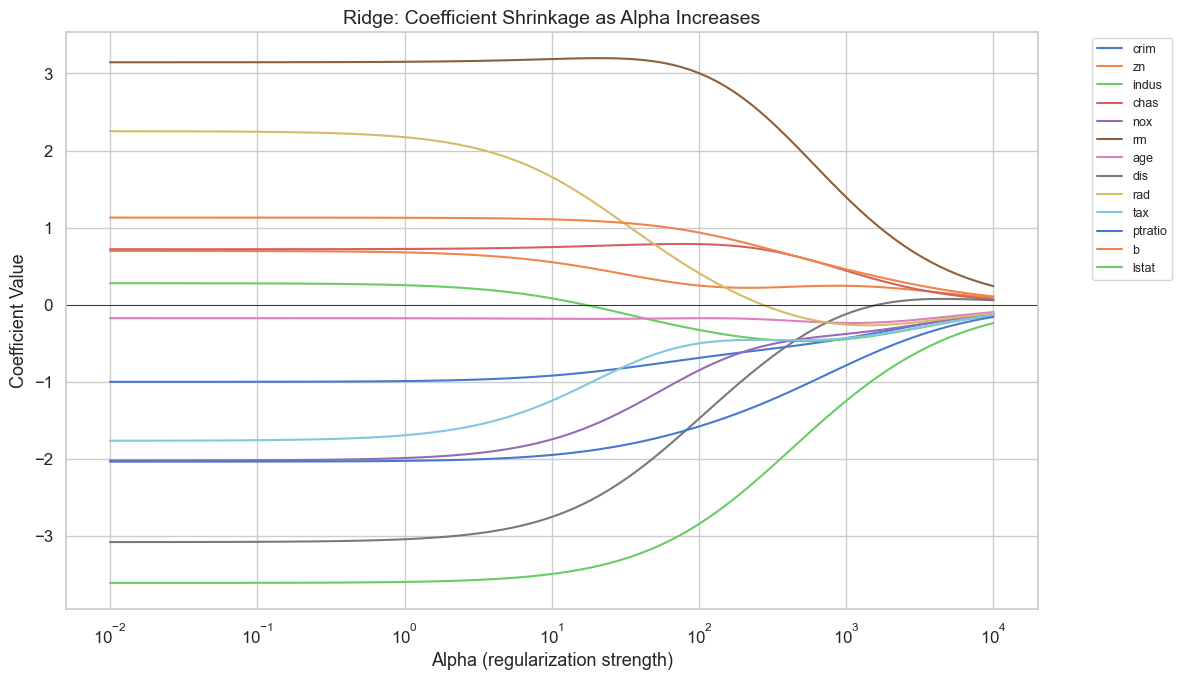

Key observation: As alpha increases, ALL coefficients shrink toward 0,
but NONE of them become exactly 0. Ridge keeps all features.


In [26]:
# ── Ridge: Coefficient path — how alpha shrinks coefficients ──
alphas = np.logspace(-2, 4, 100)
ridge_coefs = []

for a in alphas:
    ridge_temp = Ridge(alpha=a)
    ridge_temp.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge_temp.coef_)

ridge_coefs = np.array(ridge_coefs)

plt.figure(figsize=(12, 7))
for i, feat in enumerate(X.columns):
    plt.plot(alphas, ridge_coefs[:, i], lw=1.5, label=feat)

plt.xscale('log')
plt.xlabel('Alpha (regularization strength)', fontsize=13)
plt.ylabel('Coefficient Value', fontsize=13)
plt.title('Ridge: Coefficient Shrinkage as Alpha Increases', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Key observation: As alpha increases, ALL coefficients shrink toward 0,")
print("but NONE of them become exactly 0. Ridge keeps all features.")

---

## 10. Lasso Regression (L1 Regularization)

> **What is Lasso Regression?**  
> Lasso adds a penalty equal to the **sum of absolute values** of coefficients:
>
> $$\text{Loss}_{\text{Lasso}} = \sum (y_i - \hat{y}_i)^2 + \alpha \sum |w_j|$$
>
> **Key difference from Ridge:**
> - Lasso can shrink coefficients to **exactly zero**, effectively performing **automatic feature selection**.
> - This makes Lasso ideal when you suspect many features are irrelevant.
>
> | Property | Ridge (L2) | Lasso (L1) |
> |----------|-----------|-----------|
> | Penalty | $\alpha \sum w_j^2$ | $\alpha \sum |w_j|$ |
> | Coefficients → 0? | Shrinks, never exactly 0 | Can be exactly 0 |
> | Feature selection? | No | Yes |
> | Multicollinearity | Handles well (keeps all) | May drop one of correlated pair |

In [27]:
# ── Lasso Regression with scaled data ──
lasso = Lasso(alpha=0.1)
y_pred_lasso = evaluate_model("Lasso (alpha=0.1)", lasso, X_train_scaled, X_test_scaled, y_train, y_test)

  Model: Lasso (alpha=0.1)
  Train R²  : 0.7450
  Test  R²  : 0.6501
  RMSE      : 5.0652
  MAE       : 3.2418


In [28]:
# ── Lasso: Which features were selected (non-zero coefficients)? ──
lasso_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Lasso Coefficients:")
print(lasso_coef_df.to_string(index=False))

n_zero = (lasso.coef_ == 0).sum()
n_nonzero = (lasso.coef_ != 0).sum()
print(f"\nFeatures KEPT (non-zero): {n_nonzero}")
print(f"Features DROPPED (zero):  {n_zero}")
if n_zero > 0:
    dropped = X.columns[lasso.coef_ == 0].tolist()
    print(f"Dropped features: {dropped}")

Lasso Coefficients:
Feature  Coefficient
  lstat    -3.609410
     rm     3.271507
    dis    -2.284449
ptratio    -1.893335
    nox    -1.568142
      b     1.031366
   crim    -0.718365
   chas     0.698221
    rad     0.671938
    tax    -0.356654
     zn     0.259627
  indus    -0.000000
    age    -0.000000

Features KEPT (non-zero): 11
Features DROPPED (zero):  2
Dropped features: ['indus', 'age']


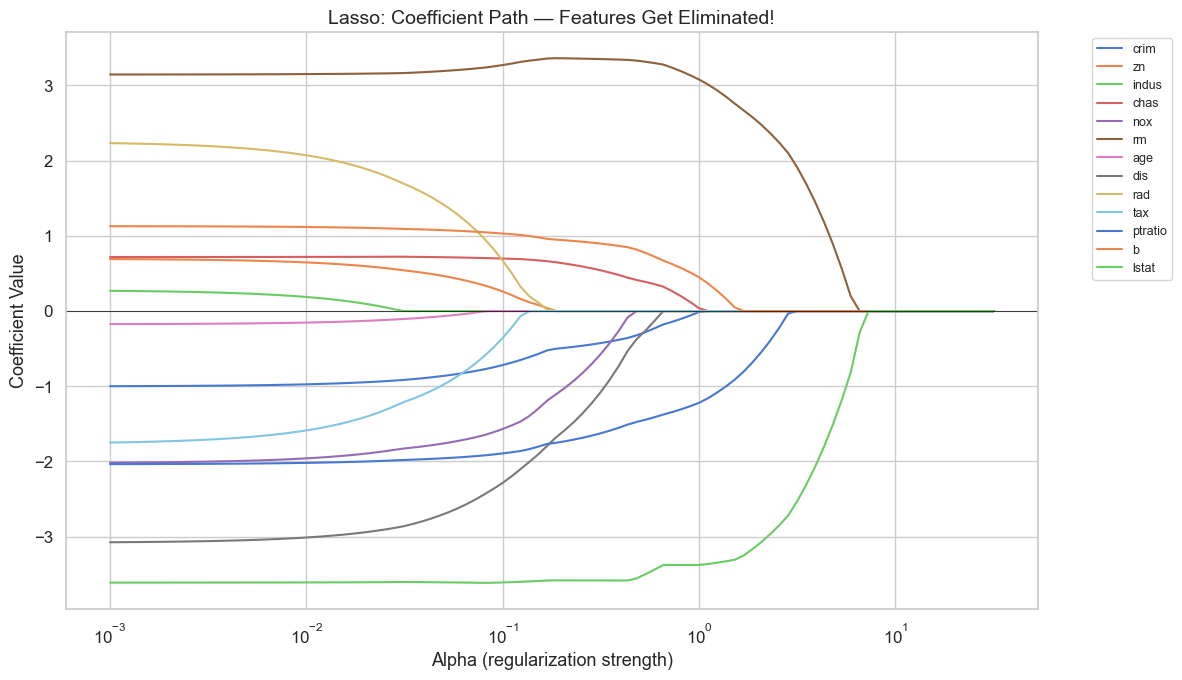

Key observation: As alpha increases, coefficients hit EXACTLY 0 and stay there.
This is Lasso's built-in FEATURE SELECTION — it eliminates irrelevant features.


In [29]:
# ── Lasso: Coefficient path — watch features get eliminated ──
alphas_lasso = np.logspace(-3, 1.5, 100)
lasso_coefs = []

for a in alphas_lasso:
    lasso_temp = Lasso(alpha=a, max_iter=10000)
    lasso_temp.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso_temp.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(12, 7))
for i, feat in enumerate(X.columns):
    plt.plot(alphas_lasso, lasso_coefs[:, i], lw=1.5, label=feat)

plt.xscale('log')
plt.xlabel('Alpha (regularization strength)', fontsize=13)
plt.ylabel('Coefficient Value', fontsize=13)
plt.title('Lasso: Coefficient Path — Features Get Eliminated!', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Key observation: As alpha increases, coefficients hit EXACTLY 0 and stay there.")
print("This is Lasso's built-in FEATURE SELECTION — it eliminates irrelevant features.")

---

## 11. Elastic Net (L1 + L2 Combined)

> **What is Elastic Net?**  
> Elastic Net combines **both** Ridge and Lasso penalties:
>
> $$\text{Loss}_{\text{ElasticNet}} = \sum (y_i - \hat{y}_i)^2 + \alpha \left[ \rho \sum |w_j| + \frac{(1 - \rho)}{2} \sum w_j^2 \right]$$
>
> Where:
> - $\alpha$ = overall regularization strength
> - $\rho$ (`l1_ratio` in sklearn) = mix between L1 and L2:
>   - `l1_ratio = 1` → pure Lasso
>   - `l1_ratio = 0` → pure Ridge
>   - `l1_ratio = 0.5` → equal mix
>
> **When to use Elastic Net?**
> - When there are **groups of correlated features** — Lasso might pick one and drop the rest, but Elastic Net tends to keep or drop them as a group.
> - When you want **feature selection** (like Lasso) but also **stability** (like Ridge).

In [30]:
# ── Elastic Net with scaled data ──
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)  # 50-50 mix of L1 and L2
y_pred_elastic = evaluate_model("Elastic Net (a=0.1, l1=0.5)", elastic, X_train_scaled, X_test_scaled, y_train, y_test)

# Show which features were kept/dropped
en_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': elastic.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\nFeatures with non-zero coefficients: {(elastic.coef_ != 0).sum()} / {len(elastic.coef_)}")
print(en_coef_df.to_string(index=False))

  Model: Elastic Net (a=0.1, l1=0.5)
  Train R²  : 0.7447
  Test  R²  : 0.6563
  RMSE      : 5.0203
  MAE       : 3.1921

Features with non-zero coefficients: 13 / 13
Feature  Coefficient
  lstat    -3.403830
     rm     3.233606
    dis    -2.175919
ptratio    -1.830041
    nox    -1.395953
      b     1.040336
    rad     0.846537
   crim    -0.761221
   chas     0.736913
    tax    -0.623952
     zn     0.322227
    age    -0.096111
  indus    -0.031008


### 11.1 Comparing Coefficients: Ridge vs Lasso vs Elastic Net

> Let's visually compare how each regularization technique treats the coefficients.

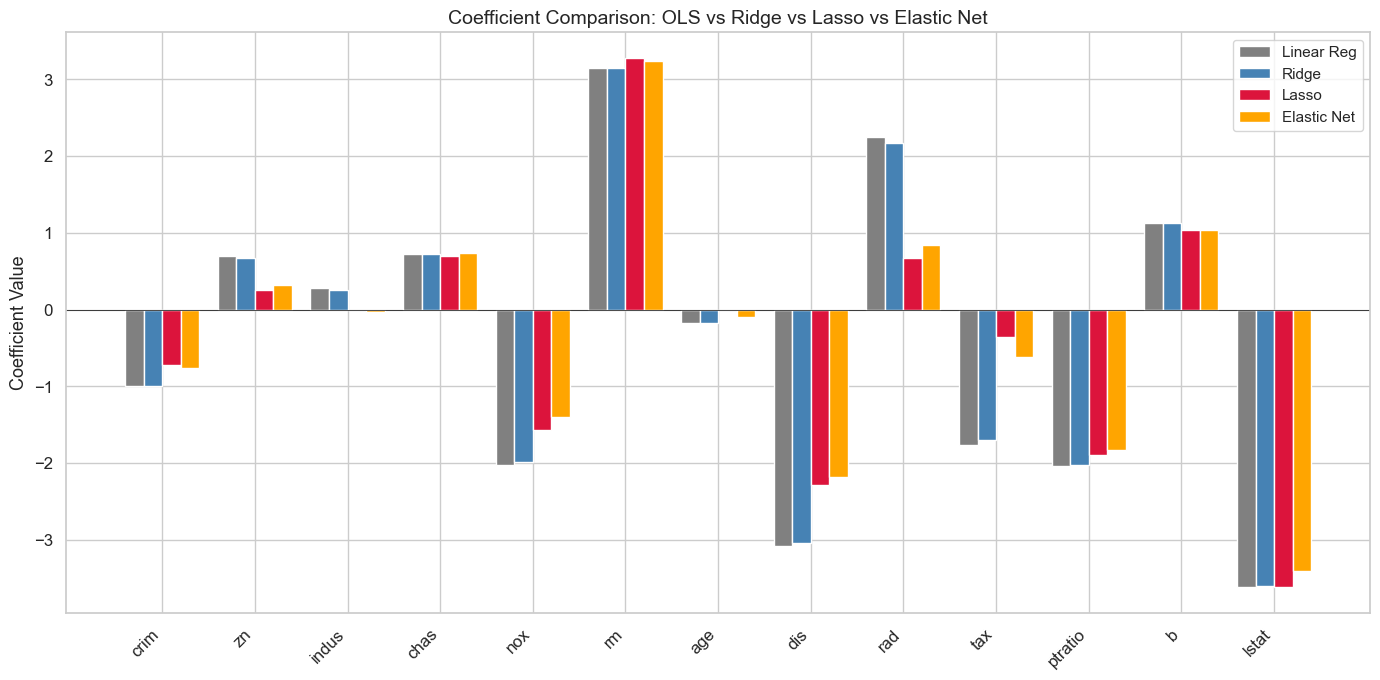

Notice how Ridge shrinks ALL coefficients, while Lasso zeros out some entirely.


In [31]:
# ── Side-by-side coefficient comparison ──
coef_compare = pd.DataFrame({
    'Feature': X.columns,
    'Linear Reg': lr_scaled.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'Elastic Net': elastic.coef_
})

fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(len(X.columns))
width = 0.2

ax.bar(x_pos - 1.5*width, lr_scaled.coef_, width, label='Linear Reg', color='gray')
ax.bar(x_pos - 0.5*width, ridge.coef_, width, label='Ridge', color='steelblue')
ax.bar(x_pos + 0.5*width, lasso.coef_, width, label='Lasso', color='crimson')
ax.bar(x_pos + 1.5*width, elastic.coef_, width, label='Elastic Net', color='orange')

ax.set_xticks(x_pos)
ax.set_xticklabels(X.columns, rotation=45, ha='right')
ax.set_ylabel('Coefficient Value', fontsize=13)
ax.set_title('Coefficient Comparison: OLS vs Ridge vs Lasso vs Elastic Net', fontsize=14)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Notice how Ridge shrinks ALL coefficients, while Lasso zeros out some entirely.")

---

## 12. Cross-Validation & Hyperparameter Tuning

> **What is Cross-Validation?**  
> Instead of relying on a single train-test split (which might be lucky or unlucky), K-Fold Cross-Validation:
> 1. Splits training data into **K equal folds** (e.g., K=5).
> 2. Trains on K−1 folds, tests on the remaining 1 fold.
> 3. Repeats K times (each fold gets to be the test fold once).
> 4. Reports the **average** score across all K folds.
>
> This gives a more **reliable** estimate of model performance.
>
> **What is Hyperparameter Tuning?**  
> Alpha in Ridge/Lasso is a **hyperparameter** — we don't learn it from data, we choose it. `GridSearchCV` tries every alpha in a grid and picks the one with the best cross-validation score.

### 12.1 Cross-Validation for Each Model

In [32]:
# ── 5-Fold Cross-Validation for each model ──
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1.0),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1),
    'Elastic Net (a=0.1, l1=0.5)': ElasticNet(alpha=0.1, l1_ratio=0.5),
}

print(f"{'Model':<35} {'Mean CV R²':>12} {'Std':>8}")
print("=" * 58)

cv_results = {}
for name, model in models_cv.items():
    # Use scaled data for regularized models
    if isinstance(model, LinearRegression):
        scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
    else:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='r2')
    
    cv_results[name] = scores
    print(f"{name:<35} {scores.mean():>12.4f} {scores.std():>8.4f}")

print("\nHigher mean R² with lower std = better and more stable model.")

Model                                 Mean CV R²      Std
Linear Regression                         0.7185   0.0784
Ridge (alpha=1)                           0.7187   0.0792
Lasso (alpha=0.1)                         0.7120   0.0918
Elastic Net (a=0.1, l1=0.5)               0.7138   0.0911

Higher mean R² with lower std = better and more stable model.


### 12.2 GridSearchCV — Finding the Best Alpha for Ridge

> `GridSearchCV` automates the process: try many alpha values, cross-validate each, pick the winner.

Best Ridge alpha: 5
Best CV R²:       0.7191


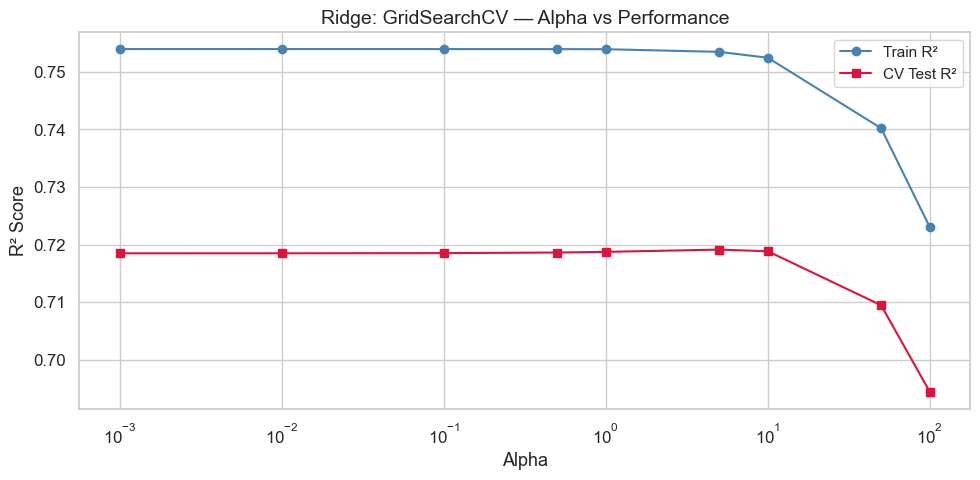

In [33]:
# ── GridSearchCV for Ridge ──
alpha_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]}

grid_ridge = GridSearchCV(Ridge(), alpha_grid, cv=kfold, scoring='r2', return_train_score=True)
grid_ridge.fit(X_train_scaled, y_train)

print(f"Best Ridge alpha: {grid_ridge.best_params_['alpha']}")
print(f"Best CV R²:       {grid_ridge.best_score_:.4f}")

# Plot alpha vs CV score
cv_res = pd.DataFrame(grid_ridge.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(cv_res['param_alpha'].astype(float), cv_res['mean_train_score'], 'o-', label='Train R²', color='steelblue')
plt.plot(cv_res['param_alpha'].astype(float), cv_res['mean_test_score'], 's-', label='CV Test R²', color='crimson')
plt.xscale('log')
plt.xlabel('Alpha', fontsize=13)
plt.ylabel('R² Score', fontsize=13)
plt.title('Ridge: GridSearchCV — Alpha vs Performance', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 12.3 GridSearchCV — Finding the Best Alpha for Lasso

Best Lasso alpha: 0.01
Best CV R²:       0.7185


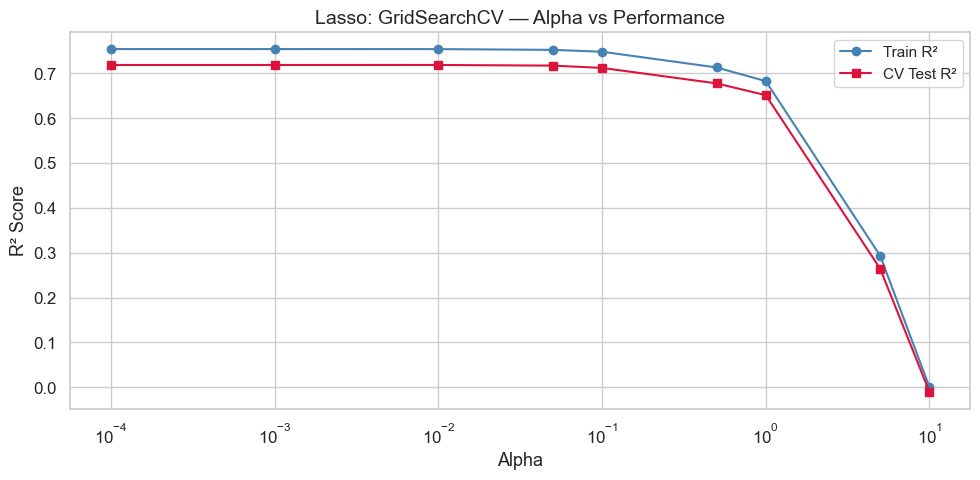

In [34]:
# ── GridSearchCV for Lasso ──
alpha_grid_lasso = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]}

grid_lasso = GridSearchCV(Lasso(max_iter=10000), alpha_grid_lasso, cv=kfold, scoring='r2', return_train_score=True)
grid_lasso.fit(X_train_scaled, y_train)

print(f"Best Lasso alpha: {grid_lasso.best_params_['alpha']}")
print(f"Best CV R²:       {grid_lasso.best_score_:.4f}")

# Plot
cv_res_l = pd.DataFrame(grid_lasso.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(cv_res_l['param_alpha'].astype(float), cv_res_l['mean_train_score'], 'o-', label='Train R²', color='steelblue')
plt.plot(cv_res_l['param_alpha'].astype(float), cv_res_l['mean_test_score'], 's-', label='CV Test R²', color='crimson')
plt.xscale('log')
plt.xlabel('Alpha', fontsize=13)
plt.ylabel('R² Score', fontsize=13)
plt.title('Lasso: GridSearchCV — Alpha vs Performance', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 12.4 GridSearchCV — Elastic Net (Tuning alpha AND l1_ratio)

In [35]:
# ── GridSearchCV for Elastic Net (2 hyperparameters!) ──
param_grid_en = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1, 5],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
}

grid_en = GridSearchCV(ElasticNet(max_iter=10000), param_grid_en, cv=kfold, scoring='r2')
grid_en.fit(X_train_scaled, y_train)

print(f"Best Elastic Net params: {grid_en.best_params_}")
print(f"Best CV R²:              {grid_en.best_score_:.4f}")

Best Elastic Net params: {'alpha': 0.01, 'l1_ratio': 0.1}
Best CV R²:              0.7190


### 12.5 Evaluate Best Tuned Models on Test Set

In [36]:
# ── Evaluate the best tuned models on the held-out test set ──
best_ridge = grid_ridge.best_estimator_
best_lasso = grid_lasso.best_estimator_
best_en = grid_en.best_estimator_

y_pred_best_ridge = evaluate_model(
    f"Best Ridge (a={grid_ridge.best_params_['alpha']})", 
    best_ridge, X_train_scaled, X_test_scaled, y_train, y_test
)
print()
y_pred_best_lasso = evaluate_model(
    f"Best Lasso (a={grid_lasso.best_params_['alpha']})", 
    best_lasso, X_train_scaled, X_test_scaled, y_train, y_test
)
print()
y_pred_best_en = evaluate_model(
    f"Best Elastic Net (a={grid_en.best_params_['alpha']}, l1={grid_en.best_params_['l1_ratio']})", 
    best_en, X_train_scaled, X_test_scaled, y_train, y_test
)

  Model: Best Ridge (a=5)
  Train R²  : 0.7506
  Test  R²  : 0.6673
  RMSE      : 4.9395
  MAE       : 3.1779

  Model: Best Lasso (a=0.01)
  Train R²  : 0.7508
  Test  R²  : 0.6682
  RMSE      : 4.9329
  MAE       : 3.1812

  Model: Best Elastic Net (a=0.01, l1=0.1)
  Train R²  : 0.7507
  Test  R²  : 0.6676
  RMSE      : 4.9370
  MAE       : 3.1796


### 12.6 Learning Curves — Diagnosing Bias vs Variance

> **Learning curves** show how performance changes as we increase training data size.
> - **High bias** (underfitting): both train and test scores are low and converge together.
> - **High variance** (overfitting): train score is high, test score is much lower — there's a gap.

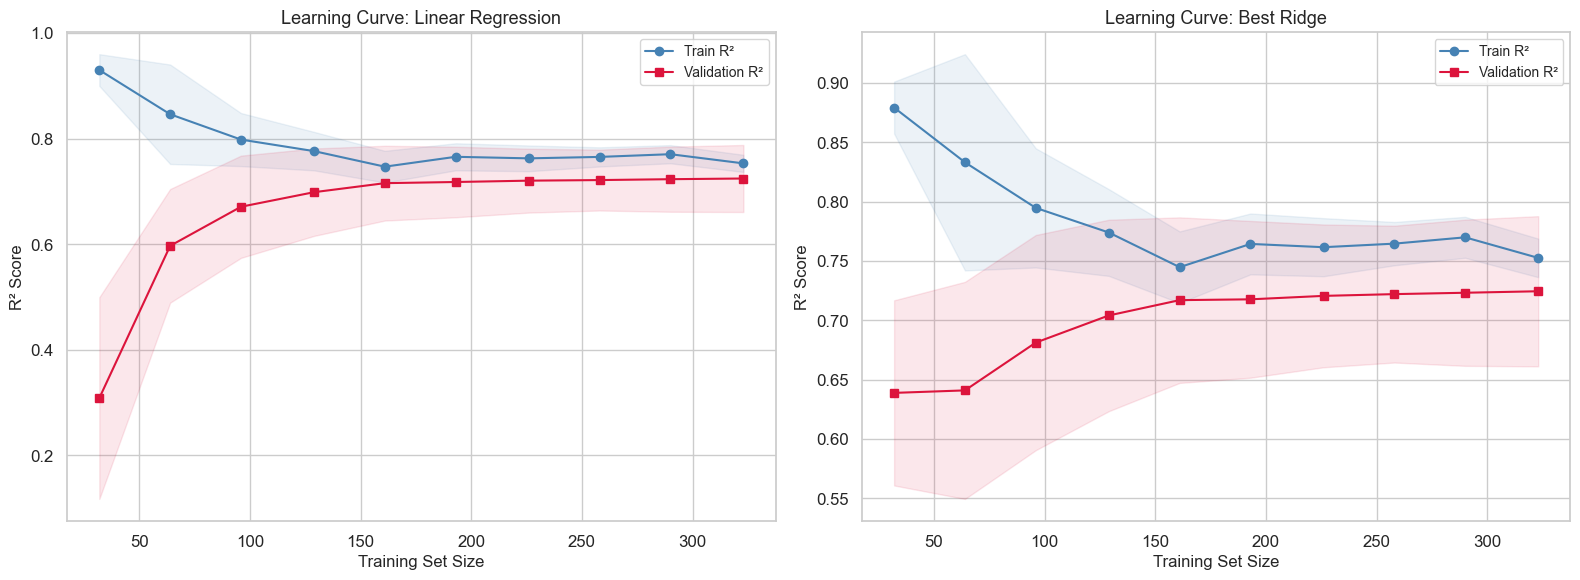

If the curves converge → model is well-tuned.
If there's a gap → model is overfitting (more data or regularization may help).


In [37]:
# ── Learning Curves for Linear Regression vs Ridge ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name, X_data in [
    (axes[0], LinearRegression(), 'Linear Regression', X_train),
    (axes[1], Ridge(alpha=grid_ridge.best_params_['alpha']), 'Best Ridge', X_train_scaled)
]:
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_data, y_train, cv=5, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
    )
    
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train R²')
    ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='steelblue')
    ax.plot(train_sizes, val_scores.mean(axis=1), 's-', color='crimson', label='Validation R²')
    ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='crimson')
    ax.set_xlabel('Training Set Size', fontsize=12)
    ax.set_ylabel('R² Score', fontsize=12)
    ax.set_title(f'Learning Curve: {name}', fontsize=13)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("If the curves converge → model is well-tuned.")
print("If there's a gap → model is overfitting (more data or regularization may help).")

---

## 13. Assumption Checking & Diagnostics

> **Linear Regression relies on 5 key assumptions.** Violating them makes the model unreliable.
>
> | # | Assumption | What It Means | How to Check |
> |---|-----------|--------------|-------------|
> | 1 | **Linearity** | Relationship between X and y is linear | Residual vs Fitted plot (should show no pattern) |
> | 2 | **Independence** | Observations are independent | Durbin-Watson test (value near 2 = good) |
> | 3 | **Normality of Residuals** | Residuals follow a normal distribution | Q-Q plot, Shapiro-Wilk test |
> | 4 | **Homoscedasticity** | Residuals have constant variance | Residual vs Fitted plot (should be a flat band) |
> | 5 | **No Multicollinearity** | Features are not highly correlated with each other | VIF (Variance Inflation Factor) |

### 13.1 Residual Plots — Checking Linearity & Homoscedasticity

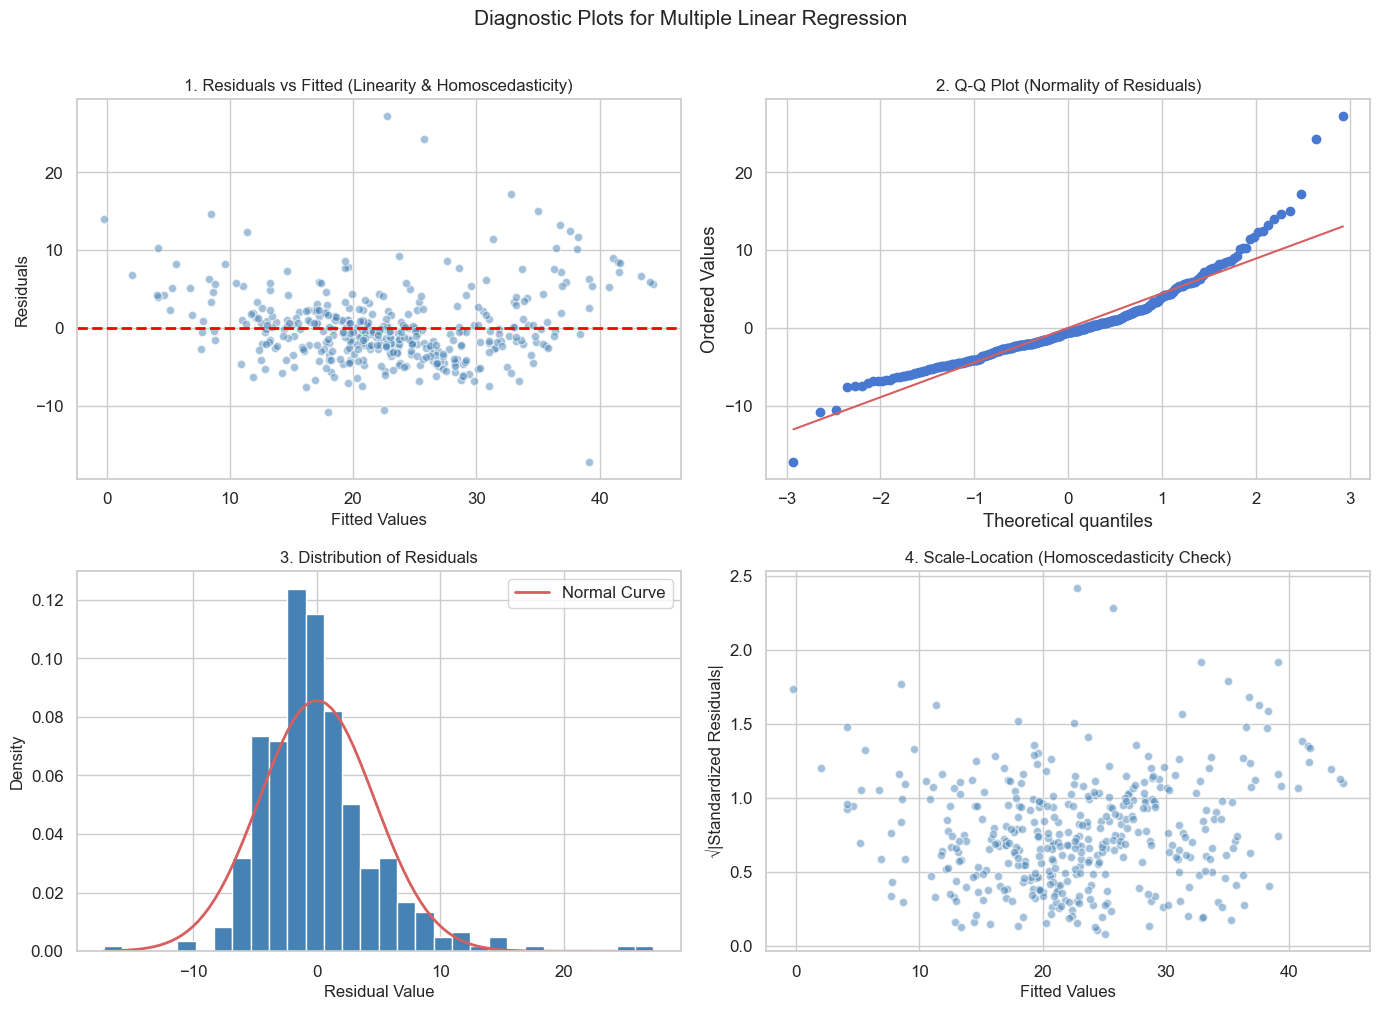

In [38]:
# ── Residual Analysis for Multiple Linear Regression ──
y_pred_train_multi = lr_multi.predict(X_train)
residuals_train = y_train - y_pred_train_multi

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted Values (Linearity + Homoscedasticity)
axes[0, 0].scatter(y_pred_train_multi, residuals_train, alpha=0.5, color='steelblue', edgecolors='white')
axes[0, 0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Fitted Values', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].set_title('1. Residuals vs Fitted (Linearity & Homoscedasticity)', fontsize=12)

# 2. Q-Q Plot (Normality of Residuals)
stats.probplot(residuals_train, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('2. Q-Q Plot (Normality of Residuals)', fontsize=12)

# 3. Histogram of Residuals
axes[1, 0].hist(residuals_train, bins=30, color='steelblue', edgecolor='white', density=True)
x_range = np.linspace(residuals_train.min(), residuals_train.max(), 100)
axes[1, 0].plot(x_range, stats.norm.pdf(x_range, residuals_train.mean(), residuals_train.std()),
                'r-', lw=2, label='Normal Curve')
axes[1, 0].set_xlabel('Residual Value', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title('3. Distribution of Residuals', fontsize=12)
axes[1, 0].legend()

# 4. Scale-Location Plot (sqrt of standardized residuals vs fitted)
standardized_res = residuals_train / residuals_train.std()
axes[1, 1].scatter(y_pred_train_multi, np.sqrt(np.abs(standardized_res)), alpha=0.5, color='steelblue', edgecolors='white')
axes[1, 1].set_xlabel('Fitted Values', fontsize=12)
axes[1, 1].set_ylabel('√|Standardized Residuals|', fontsize=12)
axes[1, 1].set_title('4. Scale-Location (Homoscedasticity Check)', fontsize=12)

plt.suptitle('Diagnostic Plots for Multiple Linear Regression', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 13.2 Normality Test (Shapiro-Wilk)

> The **Shapiro-Wilk test** formally tests whether residuals are normally distributed.
> - **H₀:** Residuals ARE normally distributed.
> - **If p-value < 0.05:** Reject H₀ → residuals are NOT normal (assumption violated).

In [39]:
# ── Shapiro-Wilk Normality Test on Residuals ──
stat, p_value = stats.shapiro(residuals_train)
print(f"Shapiro-Wilk Test:")
print(f"  Statistic: {stat:.4f}")
print(f"  p-value:   {p_value:.6f}")

if p_value < 0.05:
    print("  → p < 0.05: Residuals are NOT normally distributed (assumption violated).")
    print("    This is common with real-world data. The model may still perform well,")
    print("    but confidence intervals and p-values from statsmodels may be unreliable.")
else:
    print("  → p >= 0.05: Cannot reject normality. Residuals appear normally distributed.")

Shapiro-Wilk Test:
  Statistic: 0.9118
  p-value:   0.000000
  → p < 0.05: Residuals are NOT normally distributed (assumption violated).
    This is common with real-world data. The model may still perform well,
    but confidence intervals and p-values from statsmodels may be unreliable.


### 13.3 Multicollinearity — Variance Inflation Factor (VIF)

> **VIF** measures how much a feature's coefficient variance is inflated due to correlation with other features.
>
> | VIF Value | Interpretation |
> |-----------|---------------|
> | 1 | No correlation with other features |
> | 1–5 | Moderate correlation (usually OK) |
> | 5–10 | High correlation (investigate) |
> | > 10 | Severe multicollinearity (consider removing the feature) |

In [40]:
# ── Variance Inflation Factor (VIF) ──
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_scaled, i) for i in range(X_train_scaled.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.to_string(index=False))

# Flag problematic features
high_vif = vif_data[vif_data['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n⚠ Features with VIF > 5 (potential multicollinearity):")
    for _, row in high_vif.iterrows():
        print(f"  {row['Feature']}: VIF = {row['VIF']:.2f}")
    print("\n  Consider: Ridge handles this well. Lasso may drop one of a correlated pair.")
else:
    print("\n  All VIF values are below 5 — no severe multicollinearity detected.")

Variance Inflation Factor (VIF) for each feature:
Feature      VIF
    tax 8.943301
    rad 7.658316
    nox 4.469150
    dis 4.168578
  indus 3.877855
    age 2.989948
  lstat 2.818045
     zn 2.465631
     rm 1.947809
ptratio 1.851448
   crim 1.713187
      b 1.325121
   chas 1.096674

⚠ Features with VIF > 5 (potential multicollinearity):
  tax: VIF = 8.94
  rad: VIF = 7.66

  Consider: Ridge handles this well. Lasso may drop one of a correlated pair.


---

## 14. Statistical Validation with Statsmodels

> **Why statsmodels when we already have sklearn?**  
> Sklearn focuses on **prediction** — it gives you R², RMSE, etc.  
> Statsmodels focuses on **inference** — it tells you:
> - **p-values**: Is each feature statistically significant? (p < 0.05 → significant)
> - **F-statistic**: Is the overall model significant?
> - **Confidence intervals**: Range within which the true coefficient likely falls.
> - **Durbin-Watson**: Tests for autocorrelation in residuals (should be near 2).
> - **Adj. R²**: R² penalized for number of features (fairer comparison).
>
> **Hypothesis Testing for Each Coefficient:**
> - H₀: The coefficient = 0 (feature is useless)
> - H₁: The coefficient ≠ 0 (feature is useful)
> - If p < 0.05 → reject H₀ → feature is statistically significant

### 14.1 OLS Summary — Full Model

In [41]:
# ── Statsmodels OLS: Full model with all features ──
# Add a constant (intercept) column — statsmodels doesn't add it automatically
X_sm = sm.add_constant(X)

# Fit OLS model
ols_model = sm.OLS(y, X_sm).fit()

# Print the full summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          6.72e-135
Time:                        07:47:09   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.0

### 14.2 How to Read the OLS Summary

> **Top section:**
> - `R-squared` = proportion of variance explained by the model
> - `Adj. R-squared` = R² adjusted for number of features (use this to compare models with different numbers of features)
> - `F-statistic` & `Prob (F-statistic)` = tests if the model as a whole is significant (p < 0.05 → YES)
>
> **Middle section (coefficients table):**
> - `coef` = estimated coefficient value
> - `P>|t|` = p-value. **If < 0.05 → feature is statistically significant**
> - `[0.025, 0.975]` = 95% confidence interval for the coefficient
>
> **Bottom section:**
> - `Durbin-Watson` = test for autocorrelation (ideal value ≈ 2.0)
> - `Omnibus / Jarque-Bera` = tests for normality of residuals
> - `Cond. No.` = condition number (very large → multicollinearity problem)

### 14.3 Identifying Insignificant Features

In [42]:
# ── Extract p-values and flag insignificant features ──
pvalues_df = pd.DataFrame({
    'Feature': ols_model.pvalues.index,
    'Coefficient': ols_model.params.values,
    'p-value': ols_model.pvalues.values,
    'Significant?': ['Yes' if p < 0.05 else 'NO' for p in ols_model.pvalues.values]
}).sort_values('p-value')

print("Feature significance (sorted by p-value):")
print(pvalues_df.to_string(index=False))

insignificant = pvalues_df[pvalues_df['Significant?'] == 'NO']['Feature'].tolist()
if insignificant:
    print(f"\nInsignificant features (p >= 0.05): {insignificant}")
    print("These features do NOT significantly predict medv when other features are present.")
    print("Consider removing them or using Lasso (which drops them automatically).")

Feature significance (sorted by p-value):
Feature  Coefficient      p-value Significant?
  lstat    -0.524758 7.776912e-23          Yes
     rm     3.809865 1.979441e-18          Yes
    dis    -1.475567 6.013491e-13          Yes
ptratio    -0.952747 1.308835e-12          Yes
  const    36.459488 3.283438e-12          Yes
    nox   -17.766611 4.245644e-06          Yes
    rad     0.306049 5.070529e-06          Yes
      b     0.009312 5.728592e-04          Yes
     zn     0.046420 7.781097e-04          Yes
   crim    -0.108011 1.086810e-03          Yes
    tax    -0.012335 1.111637e-03          Yes
   chas     2.686734 1.925030e-03          Yes
  indus     0.020559 7.382881e-01           NO
    age     0.000692 9.582293e-01           NO

Insignificant features (p >= 0.05): ['indus', 'age']
These features do NOT significantly predict medv when other features are present.
Consider removing them or using Lasso (which drops them automatically).


### 14.4 Confidence Intervals for Coefficients

In [43]:
# ── 95% Confidence Intervals ──
conf_int = ols_model.conf_int()
conf_int.columns = ['Lower 2.5%', 'Upper 97.5%']
conf_int['Coefficient'] = ols_model.params

print("95% Confidence Intervals for each coefficient:")
print(conf_int.round(4).to_string())

print("\nInterpretation: If the interval contains 0, the feature may not be significant.")
print("Intervals NOT containing 0 → we're 95% confident the true coefficient is in that range.")

95% Confidence Intervals for each coefficient:
         Lower 2.5%  Upper 97.5%  Coefficient
const       26.4322      46.4868      36.4595
crim        -0.1726      -0.0434      -0.1080
zn           0.0194       0.0734       0.0464
indus       -0.1003       0.1414       0.0206
chas         0.9939       4.3796       2.6867
nox        -25.2716     -10.2616     -17.7666
rm           2.9887       4.6310       3.8099
age         -0.0253       0.0266       0.0007
dis         -1.8675      -1.0837      -1.4756
rad          0.1757       0.4364       0.3060
tax         -0.0197      -0.0049      -0.0123
ptratio     -1.2098      -0.6957      -0.9527
b            0.0040       0.0146       0.0093
lstat       -0.6244      -0.4251      -0.5248

Interpretation: If the interval contains 0, the feature may not be significant.
Intervals NOT containing 0 → we're 95% confident the true coefficient is in that range.


---

## 15. Final Model Comparison & Summary

> Let's bring everything together — compare all models side by side and pick the best one.

In [44]:
# ── Final Comparison Table ──
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df = results_df.sort_values('Test R²', ascending=False)

print("=" * 70)
print("        FINAL MODEL COMPARISON — ALL TECHNIQUES")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)

best_model = results_df.index[0]
print(f"\n  Best model by Test R²: {best_model}")
print(f"  Test R² = {results_df.loc[best_model, 'Test R²']:.4f}")
print(f"  RMSE    = {results_df.loc[best_model, 'RMSE']:.4f}")

        FINAL MODEL COMPARISON — ALL TECHNIQUES
                                   Train R²  Test R²    RMSE     MAE
Model                                                               
Polynomial LR (deg=2, all feat)      0.9409   0.8056  3.7759  2.5748
Multiple LR (all features)           0.7509   0.6688  4.9286  3.1891
Ridge (alpha=1.0)                    0.7509   0.6685  4.9308  3.1857
Best Lasso (a=0.01)                  0.7508   0.6682  4.9329  3.1812
Best Elastic Net (a=0.01, l1=0.1)    0.7507   0.6676  4.9370  3.1796
Best Ridge (a=5)                     0.7506   0.6673  4.9395  3.1779
Elastic Net (a=0.1, l1=0.5)          0.7447   0.6563  5.0203  3.1921
Lasso (alpha=0.1)                    0.7450   0.6501  5.0652  3.2418
Simple LR (lstat only)               0.5423   0.5429  5.7896  4.1848

  Best model by Test R²: Polynomial LR (deg=2, all feat)
  Test R² = 0.8056
  RMSE    = 3.7759


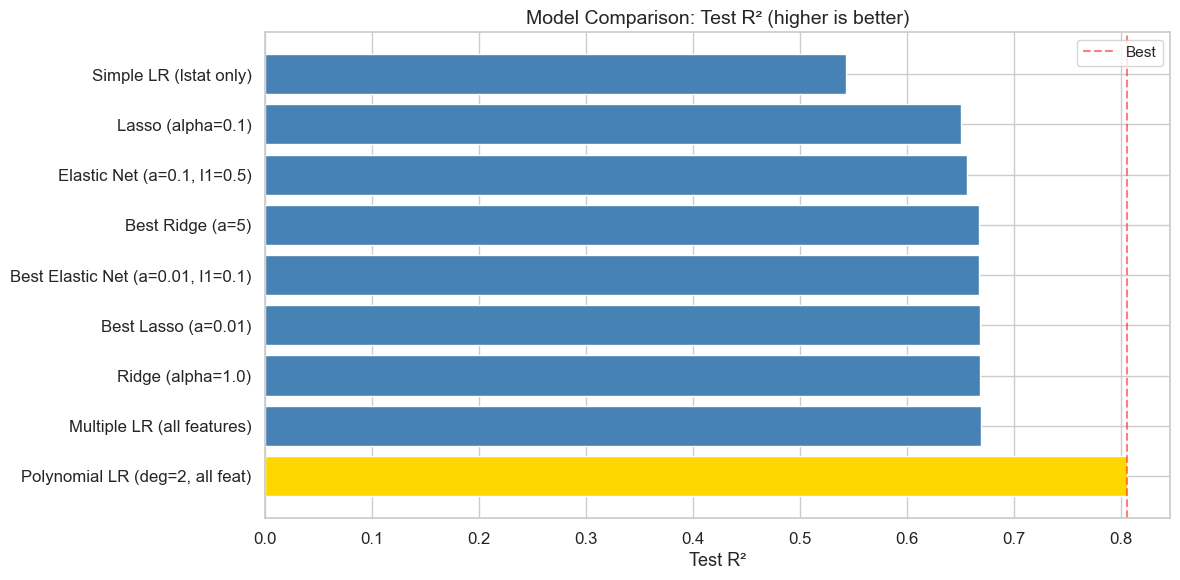

In [45]:
# ── Visual comparison: bar plot of Test R² for all models ──
plt.figure(figsize=(12, 6))
colors = ['gold' if m == best_model else 'steelblue' for m in results_df.index]
plt.barh(results_df.index, results_df['Test R²'], color=colors, edgecolor='white')
plt.xlabel('Test R²', fontsize=13)
plt.title('Model Comparison: Test R² (higher is better)', fontsize=14)
plt.axvline(x=results_df['Test R²'].max(), color='red', linestyle='--', alpha=0.5, label='Best')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

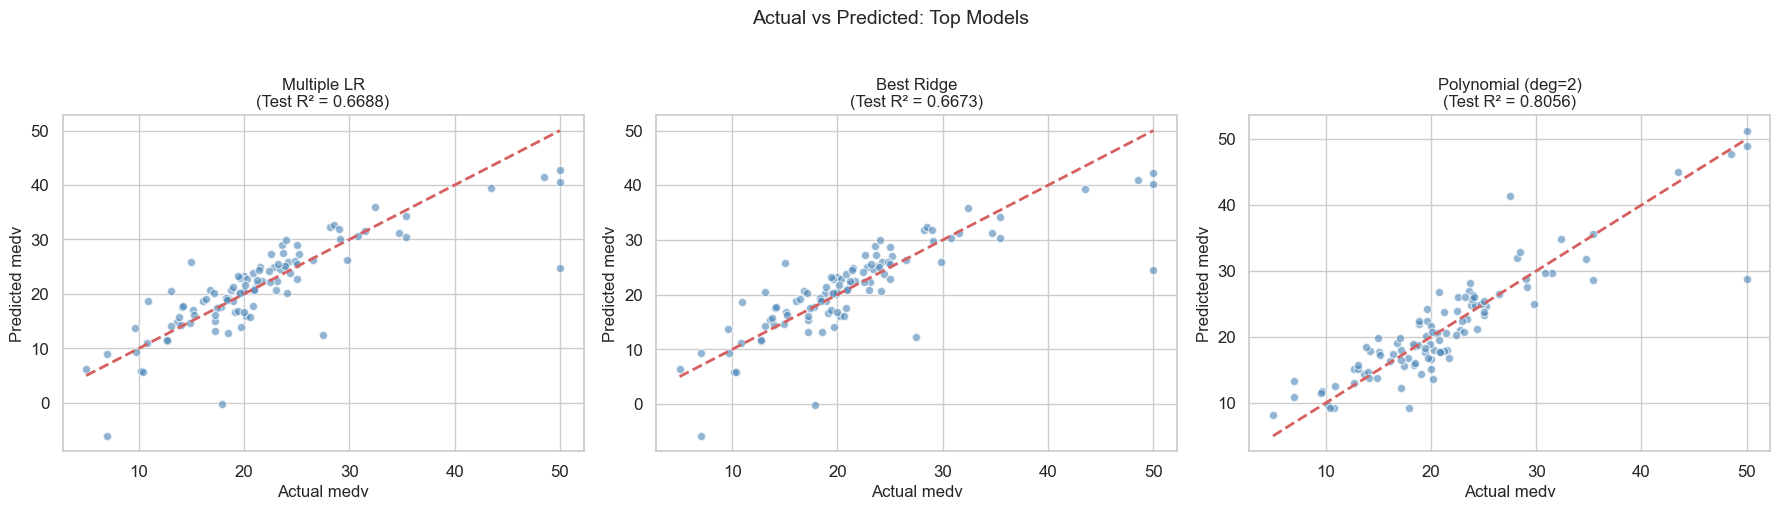

In [46]:
# ── Actual vs Predicted: Best models side by side ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

predictions = {
    'Multiple LR': y_pred_multi,
    'Best Ridge': y_pred_best_ridge,
    'Polynomial (deg=2)': y_pred_poly
}

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    r2 = r2_score(y_test, y_pred)
    ax.set_xlabel('Actual medv', fontsize=12)
    ax.set_ylabel('Predicted medv', fontsize=12)
    ax.set_title(f'{name}\n(Test R² = {r2:.4f})', fontsize=12)

plt.suptitle('Actual vs Predicted: Top Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## Key Takeaways

### Techniques Covered

| Technique | Key Idea | When to Use |
|-----------|---------|-------------|
| **Simple Linear Regression** | One feature, one straight line | Baseline, understanding a single relationship |
| **Multiple Linear Regression** | All features, one equation | When multiple features are available |
| **Polynomial Regression** | Add X², X³... for curves | When relationship is non-linear |
| **Ridge (L2)** | Penalty on squared coefficients | Multicollinearity, many features, prevent overfitting |
| **Lasso (L1)** | Penalty on absolute coefficients | Feature selection, sparse models |
| **Elastic Net** | L1 + L2 combined | Correlated features, want selection + stability |

### Evaluation Metrics Explained

| Metric | Formula | Interpretation |
|--------|---------|---------------|
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | % of variance explained (higher = better, max = 1) |
| **Adj. R²** | R² penalized for # features | Fairer comparison across models with different # features |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y - \hat{y})^2}$ | Average prediction error in same units as y (lower = better) |
| **MAE** | $\frac{1}{n}\sum|y - \hat{y}|$ | Average absolute error, less sensitive to outliers than RMSE |

### Workflow Summary

```
1. Load Data → 2. EDA → 3. Train-Test Split → 4. Simple LR (baseline)
→ 5. Multiple LR → 6. Scale Features → 7. Ridge / Lasso / Elastic Net
→ 8. Cross-Validate & Tune → 9. Check Assumptions → 10. Compare & Select Best Model
```

---
*Notebook created as a comprehensive reference for all Linear Regression techniques.*